In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
import gensim
import warnings

warnings.filterwarnings("ignore")

## DATA PREPROCESING

In [2]:
train=pd.read_csv("data train test validate/train.txt",sep=';',names=["text","emotion"])
test=pd.read_csv("data train test validate/test.txt",sep=";",names=["text","emotion"])

In [3]:
train.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [4]:
test.head()

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


In [5]:
# check for missing values
train.isnull().sum()

text       0
emotion    0
dtype: int64

In [6]:
test.isnull().sum()

text       0
emotion    0
dtype: int64

In [7]:
# checking for duplicate values 
print(train.isnull().sum())
print(test.isnull().sum())

text       0
emotion    0
dtype: int64
text       0
emotion    0
dtype: int64


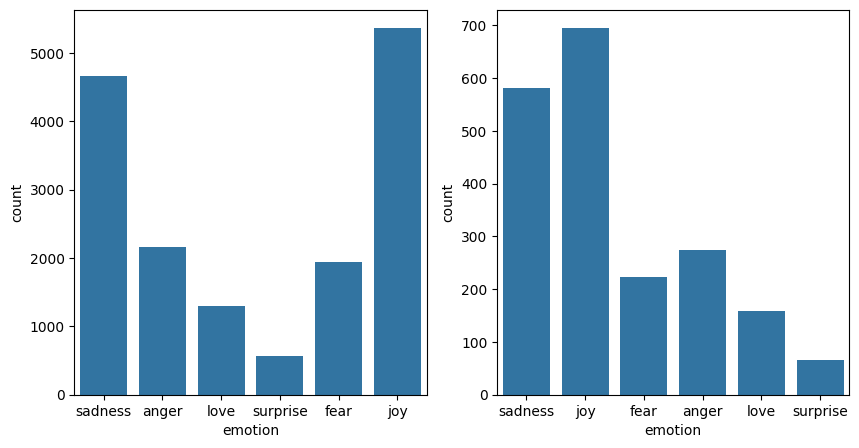

In [8]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
#train count plot 
sns.countplot(x=train["emotion"],ax=axes[0])

sns.countplot(x=test["emotion"],ax=axes[1])
plt.show()

In [9]:
train["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

In [10]:
test["emotion"].value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

In [11]:
# info 
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [12]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     2000 non-null   object
 1   emotion  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [13]:
# Basic preprocessing steps 

In [14]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
import contractions

In [15]:
# stop words'Stemmer'Lemmatizer
stop_words=set(stopwords.words('english'))

ps=PorterStemmer()

lemmatizer=WordNetLemmatizer()

In [16]:
# Creating a Single Cleaning Function 

In [17]:
def clean_text(text):
    #lower_case
    text=text.lower()

    # contractions 
    text=contractions.fix(text)
    #removing URL
    text=re.sub(r'http\S+','',text)
    
    # remove punctuation and number 
    text=re.sub(r'[^a-zA-Z\s]','',text)
    
    #tokenization
    words=word_tokenize(text)
    
    #stop word removal
    words=[word for word in words if word not in stop_words]
    
    #Lemmatization
    words=[lemmatizer.lemmatize(word) for word in words]

    # join 
    return " ".join(words)

    
    

In [18]:
# train data cleaning 
train["clean_text"]=train["text"].apply(clean_text)

In [19]:
train.head(20)

,text,emotion,clean_text
0,i didnt feel humiliated,sadness,feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,feeling little burdened lately sure
6,ive been taking or milligrams or times recomme...,surprise,taking milligram time recommended amount falle...
7,i feel as confused about life as a teenager or...,fear,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,joy,petronas year feel petronas performed well mad...
9,i feel romantic too,love,feel romantic


In [20]:
# Test Data cleaning 
test["clean_text"]=test["text"].apply(clean_text)

In [21]:
train["word_count"]=train["clean_text"].apply(lambda x:len(x.split()))

In [22]:
test.head()

,text,emotion,clean_text
0,im feeling rather rotten so im not very ambiti...,sadness,feeling rather rotten ambitious right
1,im updating my blog because i feel shitty,sadness,updating blog feel shitty
2,i never make her separate from me because i do...,sadness,never make separate ever want feel like ashamed
3,i left with my bouquet of red and yellow tulip...,joy,left bouquet red yellow tulip arm feeling slig...
4,i was feeling a little vain when i did this one,sadness,feeling little vain one


In [23]:
# Train EDA 
train["word_count"].describe()

count    16000.000000
mean         9.034500
std          5.082819
min          1.000000
25%          5.000000
50%          8.000000
75%         12.000000
max         35.000000
Name: word_count, dtype: float64

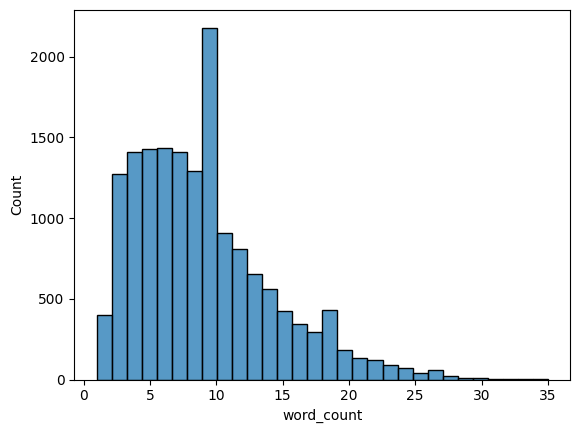

In [24]:
sns.histplot(train["word_count"],bins=30)
plt.show()

In [25]:
# Test Eda 
test["word_count"]=test["clean_text"].apply(lambda x:len(x.split()))
test["word_count"].describe()

count    2000.000000
mean        8.990500
std         5.031408
min         2.000000
25%         5.000000
50%         8.000000
75%        12.000000
max        29.000000
Name: word_count, dtype: float64

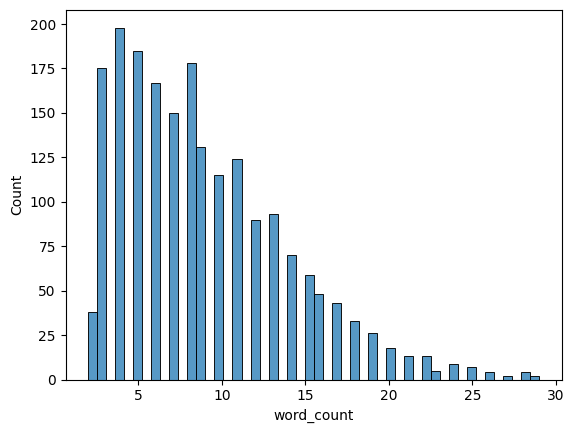

In [26]:
sns.histplot(test["word_count"],bins=50)
plt.show()

# Seprate Feature and Target (Test and Train))

In [27]:
# TRAIN SEPRATION
X_train=train["clean_text"]
y_train=train["emotion"]

In [28]:
#TEST SEPRATION
X_test=test["clean_text"]
y_test=test["emotion"]

# LABEL ENCODING OF TARGET VARIABLE

In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

y_train_en=le.fit_transform(y_train)
y_test_en=le.transform(y_test)

# FEATURE ENGINEERING 

### BAG OF WORDS 

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

In [31]:
bow=CountVectorizer()
#X_train
X_train_bow=bow.fit_transform(X_train)

# X_test 
X_test_bow=bow.transform(X_test)

In [32]:
print(len(bow.vocabulary_))
print(X_train_bow.shape)
print(bow.get_feature_names_out())
print(X_test_bow.toarray()[:10])

13390
(16000, 13390)
['aa' 'aaaaaaand' 'aaaaand' ... 'zum' 'zumba' 'zz']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [33]:
word_count=np.array(X_train_bow.sum(axis=0)).flatten()

word= bow.get_feature_names_out()

freq=pd.DataFrame({"WORD":word,"COUNT":word_count})

freq.sort_values("COUNT",ascending=False)[:20]

,WORD,COUNT
4348,feel,11506
4352,feeling,5455
6830,like,2918
11969,time,974
9502,really,942
6560,know,884
4924,get,778
7119,make,769
6891,little,736
13230,would,717


### 1.BOW Vectorization

#### Model 1.1 : Logistic Regression (BOW)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [35]:
lr=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr.fit(X_train_bow,y_train_en)

# predict on test and train 
y_train_predict_lr=lr.predict(X_train_bow)
y_test_predict_lr= lr.predict(X_test_bow)

#Accuracy 
train_accuracy_lr= accuracy_score(y_train_en,y_train_predict_lr)
test_accuracy_lr =accuracy_score(y_test_en,y_test_predict_lr)

print("Train Accuracy:",train_accuracy_lr)
print("\n")
print("Test Accuracy:",test_accuracy_lr)

print("\n")

#Confusion Matrix 
cm_lr=confusion_matrix(y_test_en,y_test_predict_lr)
print("Confusion_matrix")
print(cm_lr)

print("\n")

#classification Report
cr_lr=classification_report(y_test_en,y_test_predict_lr)
print("Classification_Report")
print(cr_lr)

Train Accuracy: 0.98375


Test Accuracy: 0.8915


Confusion_matrix
[[241   9   9   1  15   0]
 [  9 189   4   1  16   5]
 [  6   4 645  30   5   5]
 [  3   1  32 120   2   1]
 [ 14   6  11   2 547   1]
 [  1  14   8   0   2  41]]


Classification_Report
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       275
           1       0.85      0.84      0.85       224
           2       0.91      0.93      0.92       695
           3       0.78      0.75      0.77       159
           4       0.93      0.94      0.94       581
           5       0.77      0.62      0.69        66

    accuracy                           0.89      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.89      0.89      0.89      2000



#### Model 1.2 XGBOOST(BOW)

In [36]:
from xgboost import XGBClassifier

In [37]:
xgb=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [38]:
xgb.fit(X_train_bow,y_train_en)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [39]:
# predict on test and train 
y_train_predict_xgb=xgb.predict(X_train_bow)
y_test_predict_xgb= xgb.predict(X_test_bow)

#Accuracy 
train_accuracy_xgb= accuracy_score(y_train_en,y_train_predict_xgb)
test_accuracy_xgb =accuracy_score(y_test_en,y_test_predict_xgb)

print("Train Accuracy:",train_accuracy_xgb)
print("\n")
print("Test Accuracy:",test_accuracy_xgb)

print("\n")

#Confusion Matrix 
cm_xgb=confusion_matrix(y_test_en,y_test_predict_xgb)
print("Confusion_matrix")
print(cm_xgb)

print("\n")

#classification Report
cr_xgb=classification_report(y_test_en,y_test_predict_xgb)
print("Classification_Report")
print(cr_xgb)

Train Accuracy: 0.9206875


Test Accuracy: 0.878


Confusion_matrix
[[235   9  21   1   8   1]
 [  4 195   4   0   7  14]
 [  3   4 631  43   6   8]
 [  2   0  26 129   0   2]
 [ 12   5  33   4 522   5]
 [  0  10  12   0   0  44]]


Classification_Report
              precision    recall  f1-score   support

           0       0.92      0.85      0.89       275
           1       0.87      0.87      0.87       224
           2       0.87      0.91      0.89       695
           3       0.73      0.81      0.77       159
           4       0.96      0.90      0.93       581
           5       0.59      0.67      0.63        66

    accuracy                           0.88      2000
   macro avg       0.82      0.83      0.83      2000
weighted avg       0.88      0.88      0.88      2000



#### Model 1.3 Linear SVM(BOW)

In [40]:
from sklearn.svm import LinearSVC

In [41]:
svm=LinearSVC(random_state=42)

In [42]:
svm.fit(X_train_bow,y_train_en)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [43]:
# predict on test and train 
y_train_predict_svm=svm.predict(X_train_bow)
y_test_predict_svm= svm.predict(X_test_bow)

#Accuracy 
train_accuracy_svm= accuracy_score(y_train_en,y_train_predict_svm)
test_accuracy_svm =accuracy_score(y_test_en,y_test_predict_svm)

print("Train Accuracy:",train_accuracy_svm)
print("\n")
print("Test Accuracy:",test_accuracy_svm)

print("\n")

#Confusion Matrix 
cm_svm=confusion_matrix(y_test_en,y_test_predict_svm)
print("Confusion_matrix")
print(cm_svm)

print("\n")

#classification Report
cr_svm=classification_report(y_test_en,y_test_predict_svm)
print("Classification_Report")
print(cr_svm)

Train Accuracy: 0.9929375


Test Accuracy: 0.8885


Confusion_matrix
[[237   7   7   4  19   1]
 [  9 193   3   0  15   4]
 [  4   5 637  36   6   7]
 [  3   3  27 123   1   2]
 [ 16   7  14   2 541   1]
 [  2  11   5   0   2  46]]


Classification_Report
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       275
           1       0.85      0.86      0.86       224
           2       0.92      0.92      0.92       695
           3       0.75      0.77      0.76       159
           4       0.93      0.93      0.93       581
           5       0.75      0.70      0.72        66

    accuracy                           0.89      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.89      0.89      0.89      2000



### 2.TFIDF (Vectorization)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [45]:
tfidf=TfidfVectorizer()

In [46]:
# Train Vectorizer
X_train_tfidf=tfidf.fit_transform(X_train)

#Test Vectorizer

X_test_tfidf=tfidf.transform(X_test)

#### 2.Modelling with tfidf vectorization 

#### 2.1 Logistic Regression (tfidf)

In [47]:
lr_tf=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr_tf.fit(X_train_tfidf,y_train_en)

# predict on test and train 
y_train_predict_lr_tf=lr_tf.predict(X_train_tfidf)
y_test_predict_lr_tf= lr_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_lr_tf= accuracy_score(y_train_en,y_train_predict_lr_tf)
test_accuracy_lr_tf =accuracy_score(y_test_en,y_test_predict_lr_tf)

print("Train Accuracy:",train_accuracy_lr_tf)
print("\n")
print("Test Accuracy:",test_accuracy_lr_tf)

print("\n")

#Confusion Matrix 
cm_lr_tf=confusion_matrix(y_test_en,y_test_predict_lr_tf)
print("Confusion_matrix")
print(cm_lr_tf)

print("\n")

#classification Report
cr_lr_tf=classification_report(y_test_en,y_test_predict_lr_tf)
print("Classification_Report")
print(cr_lr_tf)

Train Accuracy: 0.94575


Test Accuracy: 0.873


Confusion_matrix
[[228   6  19   1  21   0]
 [  9 181  11   0  22   1]
 [  4   4 662  19   5   1]
 [  3   0  48 100   8   0]
 [ 13   4  22   1 541   0]
 [  1  13  14   0   4  34]]


Classification_Report
              precision    recall  f1-score   support

           0       0.88      0.83      0.86       275
           1       0.87      0.81      0.84       224
           2       0.85      0.95      0.90       695
           3       0.83      0.63      0.71       159
           4       0.90      0.93      0.92       581
           5       0.94      0.52      0.67        66

    accuracy                           0.87      2000
   macro avg       0.88      0.78      0.81      2000
weighted avg       0.87      0.87      0.87      2000



#### Model 2.2 XGBOOST USING (TFIDF)

In [68]:
xgb_tf=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [69]:
xgb_tf.fit(X_train_tfidf,y_train_en)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [70]:
# predict on test and train 
y_train_predict_xgb_tf=xgb_tf.predict(X_train_tfidf)
y_test_predict_xgb_tf= xgb_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_xgb_tf= accuracy_score(y_train_en,y_train_predict_xgb_tf)
test_accuracy_xgb_tf =accuracy_score(y_test_en,y_test_predict_xgb_tf)

print("Train Accuracy:",train_accuracy_xgb_tf)
print("\n")
print("Test Accuracy:",test_accuracy_xgb_tf)

print("\n")

#Confusion Matrix 
cm_xgb_tf=confusion_matrix(y_test_en,y_test_predict_xgb_tf)
print("Confusion_matrix")
print(cm_xgb_tf)

print("\n")

#classification Report
cr_xgb_tf=classification_report(y_test_en,y_test_predict_xgb_tf)
print("Classification_Report")
print(cr_xgb_tf)

Train Accuracy: 0.9366875


Test Accuracy: 0.878


Confusion_matrix
[[234   8  21   1  10   1]
 [  5 198   3   0   6  12]
 [  3   4 629  45   6   8]
 [  2   0  29 126   0   2]
 [ 12   5  34   2 523   5]
 [  0  11   9   0   0  46]]


Classification_Report
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       275
           1       0.88      0.88      0.88       224
           2       0.87      0.91      0.89       695
           3       0.72      0.79      0.76       159
           4       0.96      0.90      0.93       581
           5       0.62      0.70      0.66        66

    accuracy                           0.88      2000
   macro avg       0.83      0.84      0.83      2000
weighted avg       0.88      0.88      0.88      2000



#### Model 2.3 Liner svm (TFIDF)

In [51]:
svm_tf=LinearSVC(random_state=42)

In [52]:
svm_tf.fit(X_train_tfidf,y_train_en)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [53]:
# predict on test and train 
y_train_predict_svm_tf=svm_tf.predict(X_train_tfidf)
y_test_predict_svm_tf= svm_tf.predict(X_test_tfidf)

#Accuracy 
train_accuracy_svm_tf= accuracy_score(y_train_en,y_train_predict_svm_tf)
test_accuracy_svm_tf =accuracy_score(y_test_en,y_test_predict_svm_tf)

print("Train Accuracy:",train_accuracy_svm_tf)
print("\n")
print("Test Accuracy:",test_accuracy_svm_tf)

print("\n")

#Confusion Matrix 
cm_svm_tf=confusion_matrix(y_test_en,y_test_predict_svm_tf)
print("Confusion_matrix")
print(cm_svm_tf)

print("\n")

#classification Report
cr_svm_tf=classification_report(y_test_en,y_test_predict_svm_tf)
print("Classification_Report")
print(cr_svm_tf)

Train Accuracy: 0.9858125


Test Accuracy: 0.893


Confusion_matrix
[[242   6   8   2  16   1]
 [ 10 189   4   0  18   3]
 [  4   3 643  32   5   8]
 [  2   0  28 126   2   1]
 [ 18   5  14   1 542   1]
 [  1  12   6   0   3  44]]


Classification_Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       275
           1       0.88      0.84      0.86       224
           2       0.91      0.93      0.92       695
           3       0.78      0.79      0.79       159
           4       0.92      0.93      0.93       581
           5       0.76      0.67      0.71        66

    accuracy                           0.89      2000
   macro avg       0.86      0.84      0.85      2000
weighted avg       0.89      0.89      0.89      2000



### 3.WORD2VEC (Vectorization)

In [54]:
# tokenize train and test before word2vec

tokenized_train=[sentence.split() for sentence in X_train]

tokenized_test=[sentence.split() for sentence in X_test]

In [55]:
from gensim.models import Word2Vec

In [56]:
w2v=Word2Vec(sentences=tokenized_train,vector_size=100,window=5,min_count=2,workers=4)

In [57]:
w2v.wv["happy"]

array([-0.13767496,  0.40186125,  0.3035708 ,  0.29602444, -0.16942483,
       -0.85682476,  0.19054835,  0.6600193 , -0.27773127, -0.33377582,
       -0.15632242, -0.6906476 , -0.11999177,  0.51358604,  0.14885707,
       -0.33050466,  0.19238897, -0.47326997, -0.29726917, -0.89384997,
        0.3423535 ,  0.4160265 ,  0.4352856 , -0.19170405, -0.10305377,
       -0.05592336, -0.51869756, -0.19356035, -0.45067695,  0.1925945 ,
        0.4719061 ,  0.03896749,  0.20359893, -0.12824531, -0.40660542,
        0.4317483 ,  0.1747399 , -0.5150459 , -0.23314378, -0.6193846 ,
       -0.1101227 , -0.243017  , -0.27975395, -0.13090031,  0.38427123,
       -0.2085274 , -0.51491016,  0.1223046 ,  0.2221716 ,  0.40480155,
        0.11981236, -0.3785755 , -0.11431748, -0.05219713, -0.23805049,
        0.2198194 ,  0.3624521 , -0.04265628, -0.65833044,  0.23879631,
       -0.04987848, -0.10158785, -0.19010653, -0.00099892, -0.4720445 ,
        0.5540549 , -0.22635566,  0.4079322 , -0.5515052 ,  0.51

In [58]:
def document_vector(doc):
    words=doc.split()

    vectors= [w2v.wv[word] for word in words if word in w2v.wv]

    if len(vectors)==0:
        return np.zeros(100)
    return np.mean(vectors,axis=0)

In [59]:
X_train_w2v=np.array([document_vector(doc) for doc in X_train])

X_test_w2v=np.array([document_vector(doc) for doc in X_test])

In [60]:
X_train_w2v.shape

(16000, 100)

#### 3.1 Logistic Regression (W2V VECTORIZATION)

In [61]:
lr_w2v=LogisticRegression(max_iter=1000,random_state=42)

# fitting 
lr_w2v.fit(X_train_w2v,y_train_en)

# predict on test and train 
y_train_predict_lr_w2v=lr_w2v.predict(X_train_w2v)
y_test_predict_lr_w2v= lr_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_lr_w2v= accuracy_score(y_train_en,y_train_predict_lr_w2v)
test_accuracy_lr_w2v =accuracy_score(y_test_en,y_test_predict_lr_w2v)

print("Train Accuracy:",train_accuracy_lr_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_lr_w2v)

print("\n")

#Confusion Matrix 
cm_lr_w2v=confusion_matrix(y_test_en,y_test_predict_lr_w2v)
print("Confusion_matrix")
print(cm_lr_w2v)

print("\n")

#classification Report
cr_lr_w2v=classification_report(y_test_en,y_test_predict_lr_w2v)
print("Classification_Report")
print(cr_lr_w2v)

Train Accuracy: 0.363375


Test Accuracy: 0.379


Confusion_matrix
[[  0   0 215   0  60   0]
 [  0   0 155   0  69   0]
 [  0   0 595   0 100   0]
 [  0   0 136   0  23   0]
 [  0   0 418   0 163   0]
 [  0   0  49   0  17   0]]


Classification_Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.38      0.86      0.53       695
           3       0.00      0.00      0.00       159
           4       0.38      0.28      0.32       581
           5       0.00      0.00      0.00        66

    accuracy                           0.38      2000
   macro avg       0.13      0.19      0.14      2000
weighted avg       0.24      0.38      0.28      2000



#### 3.2 XGBOOST(W2V Vectorization)

In [62]:
xgb_w2v=XGBClassifier(objective='multi:softmax',num_class=len(set(y_train)),n_estimators=200,
                  max_depth=6,learning_rate=0.1,random_state=42)

In [63]:
xgb_w2v.fit(X_train_w2v,y_train_en)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [64]:
# predict on test and train 
y_train_predict_xgb_w2v=xgb_w2v.predict(X_train_w2v)
y_test_predict_xgb_w2v= xgb_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_xgb_w2v= accuracy_score(y_train_en,y_train_predict_xgb_w2v)
test_accuracy_xgb_w2v =accuracy_score(y_test_en,y_test_predict_xgb_w2v)

print("Train Accuracy:",train_accuracy_xgb_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_xgb_w2v)

print("\n")

#Confusion Matrix 
cm_xgb_w2v=confusion_matrix(y_test_en,y_test_predict_xgb_w2v)
print("Confusion_matrix")
print(cm_xgb_w2v)

print("\n")

#classification Report
cr_xgb_w2v=classification_report(y_test_en,y_test_predict_xgb_w2v)
print("Classification_Report")
print(cr_xgb_w2v)

Train Accuracy: 0.840125


Test Accuracy: 0.386


Confusion_matrix
[[ 15   6 152   0 102   0]
 [  4  14 119   0  87   0]
 [ 12  10 464   7 201   1]
 [  4   1 106   6  42   0]
 [  9  15 284   2 271   0]
 [  1   1  32   0  30   2]]


Classification_Report
              precision    recall  f1-score   support

           0       0.33      0.05      0.09       275
           1       0.30      0.06      0.10       224
           2       0.40      0.67      0.50       695
           3       0.40      0.04      0.07       159
           4       0.37      0.47      0.41       581
           5       0.67      0.03      0.06        66

    accuracy                           0.39      2000
   macro avg       0.41      0.22      0.21      2000
weighted avg       0.38      0.39      0.33      2000



#### 3.3 Liner SVM (W2V VECTORIZATION)

In [65]:
svm_w2v=LinearSVC(random_state=42)

In [66]:
svm_w2v.fit(X_train_w2v,y_train_en)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [67]:
# predict on test and train 
y_train_predict_svm_w2v=svm_w2v.predict(X_train_w2v)
y_test_predict_svm_w2v= svm_w2v.predict(X_test_w2v)

#Accuracy 
train_accuracy_svm_w2v= accuracy_score(y_train_en,y_train_predict_svm_w2v)
test_accuracy_svm_w2v =accuracy_score(y_test_en,y_test_predict_svm_w2v)

print("Train Accuracy:",train_accuracy_svm_w2v)
print("\n")
print("Test Accuracy:",test_accuracy_svm_w2v)

print("\n")

#Confusion Matrix 
cm_svm_w2v=confusion_matrix(y_test_en,y_test_predict_svm_w2v)
print("Confusion_matrix")
print(cm_svm_w2v)

print("\n")

#classification Report
cr_svm_w2v=classification_report(y_test_en,y_test_predict_svm_w2v)
print("Classification_Report")
print(cr_svm_w2v)

Train Accuracy: 0.3900625


Test Accuracy: 0.4065


Confusion_matrix
[[  0   0 188   0  87   0]
 [  0   0 145   0  79   0]
 [  0   0 580   0 115   0]
 [  0   0 126   0  33   0]
 [  0   0 348   0 233   0]
 [  0   0  46   0  20   0]]


Classification_Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.40      0.83      0.55       695
           3       0.00      0.00      0.00       159
           4       0.41      0.40      0.41       581
           5       0.00      0.00      0.00        66

    accuracy                           0.41      2000
   macro avg       0.14      0.21      0.16      2000
weighted avg       0.26      0.41      0.31      2000



# Hyper Parameter Tuning Using RANDOMIZED SEARCH CV 

####  XGBOOST-TFIDF 

In [72]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
xgb_tune=XGBClassifier(objective="multi:softmax",num_class=len(set(y_train_en)),random_state=42)

In [ ]:
param_dist={ 'n_extimators':[100,200,300,400,500],
             'max_depth':[3,4,5,6,7,8,9,10,11],
             'learning_rate':[0.01,0.05,0.1,0.2,0.3],
             'subsample':[0.7,0.8,0.9,1.0],
             'colsample_bytree':[0.7,0.8,0.9,1.0],
             'min_child_weight':[1,3,5,7],
             'gamma':[0,0.,0.2,0.3]
           }



In [ ]:
random_search=RandomizedSearchCV(estimator=xgb_tune,param_distribution=param_dist

In [73]:
! git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   .ipynb_checkpoints/nlp assingment-checkpoint.ipynb
	modified:   nlp assingment.ipynb
	deleted:    ~$signment (2).docx

no changes added to commit (use "git add" and/or "git commit -a")
